In [1]:
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from matplotlib import pyplot as plt
from maze import Maze

In [2]:
N = 1000
height = 50
width = 50
seeds = 10

rows = []

for _ in tqdm(range(N), desc="Generating mazes"):
    maze = Maze(height, width, seeds)
    rows.append(maze.collect_metrics())

df = pd.DataFrame(rows)
df.head()



Generating mazes:   0%|          | 0/1000 [00:00<?, ?it/s]

Generating mazes: 100%|██████████| 1000/1000 [00:51<00:00, 19.56it/s]


,n_cells,height_width_ratio,n_seeds,branching_factor,dead_ends,leaf_fraction,solution_length,longest_path,solution_tortuosity
0,2500,1.0,10,1.449536,776,0.3104,146,194,2.106890
1,2500,1.0,10,1.454598,782,0.3128,126,155,1.818275
2,2500,1.0,10,1.454598,782,0.3128,112,155,1.616244
3,2500,1.0,10,1.445344,771,0.3084,114,131,1.645106
4,2500,1.0,10,1.455446,783,0.3132,108,146,1.558521


In [3]:
print(df.describe())

       n_cells  height_width_ratio  n_seeds  branching_factor    dead_ends  \
count   1000.0              1000.0   1000.0       1000.000000  1000.000000   
mean    2500.0                 1.0     10.0          1.453890   781.025000   
std        0.0                 0.0      0.0          0.013059    15.434591   
min     2500.0                 1.0     10.0          1.416667   736.000000   
25%     2500.0                 1.0     10.0          1.444509   770.000000   
50%     2500.0                 1.0     10.0          1.453752   781.000000   
75%     2500.0                 1.0     10.0          1.463115   792.000000   
max     2500.0                 1.0     10.0          1.492832   826.000000   

       leaf_fraction  solution_length  longest_path  solution_tortuosity  
count    1000.000000      1000.000000    1000.00000          1000.000000  
mean        0.312410       122.698000     147.86100             1.770624  
std         0.006174        14.535201      22.20195             0.209754

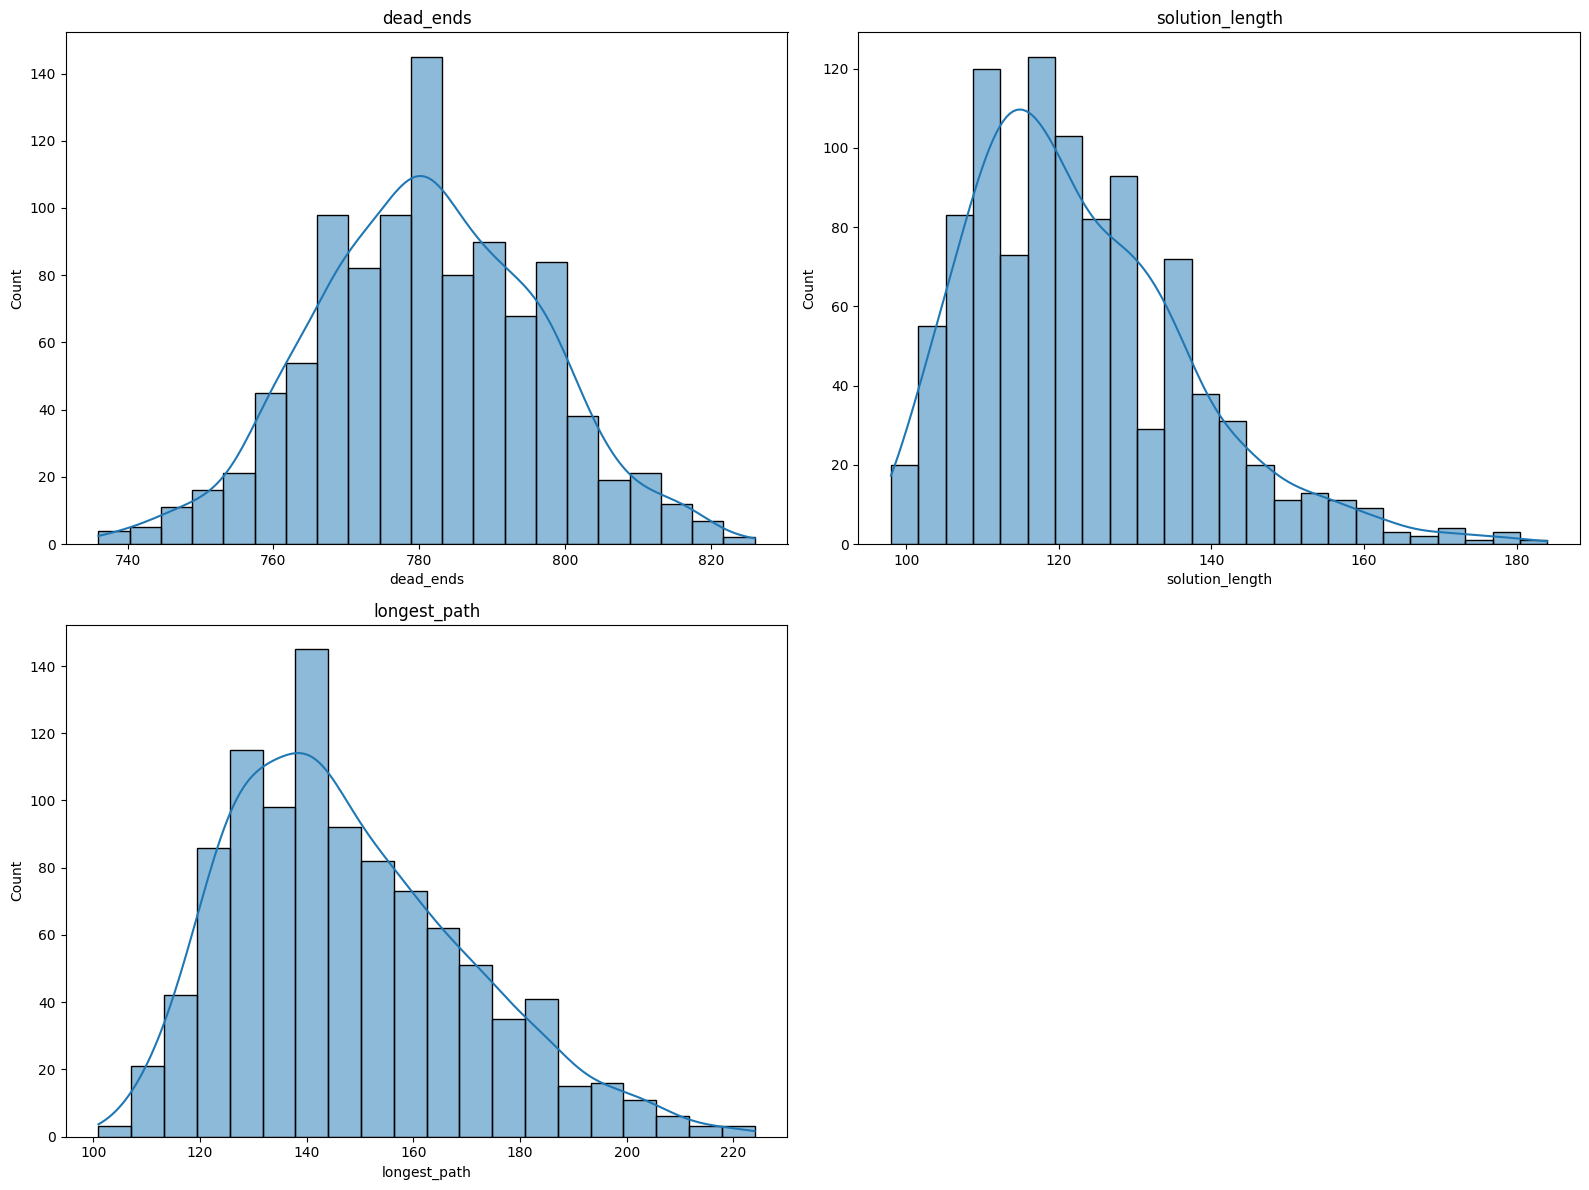

In [4]:
metrics = [
    "dead_ends",
    "solution_length",
    "longest_path",
]

plt.figure(figsize=(16, 12))

for i, m in enumerate(metrics):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[m], kde=True)
    plt.title(m)

plt.tight_layout()
plt.show()


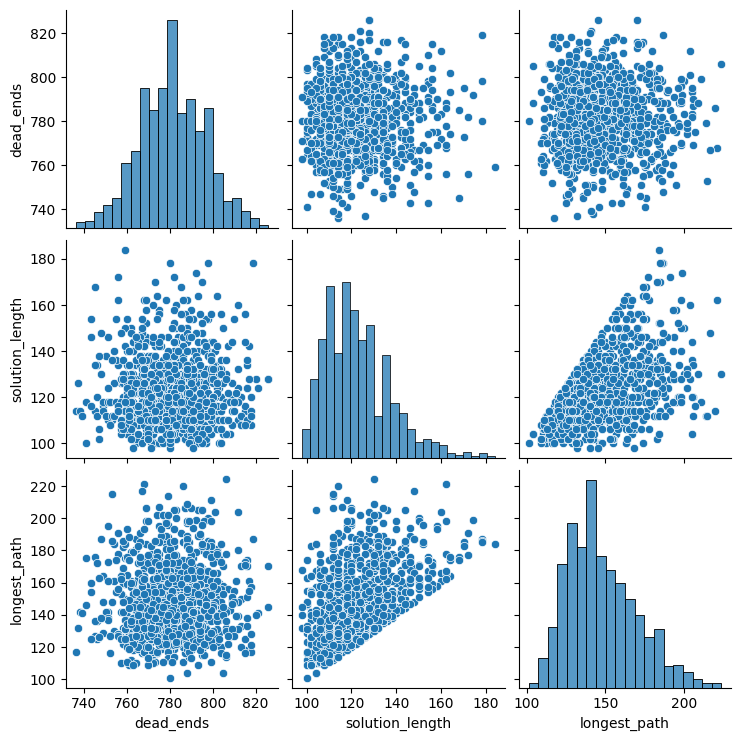

In [5]:
sns.pairplot(df[metrics])
plt.show()



In [6]:
seed_values = range(1, 50)
runs_per_seed = 30

rows = []

for s in tqdm(seed_values, desc="Varying seeds"):
    for _ in range(runs_per_seed):
        maze = Maze(50, 50, seeds=s)
        stats = maze.collect_metrics()
        rows.append(stats)

df_seeds = pd.DataFrame(rows)
df_seeds.head()


Varying seeds: 100%|██████████| 49/49 [01:17<00:00,  1.57s/it]


,n_cells,height_width_ratio,n_seeds,branching_factor,dead_ends,leaf_fraction,solution_length,longest_path,solution_tortuosity
0,2500,1.0,1,1.419886,740,0.2960,110,123,1.587383
1,2500,1.0,1,1.432913,756,0.3024,100,139,1.443075
2,2500,1.0,1,1.415062,734,0.2936,104,125,1.500798
3,2500,1.0,1,1.403144,719,0.2876,104,157,1.500798
4,2500,1.0,1,1.423121,744,0.2976,102,103,1.471937


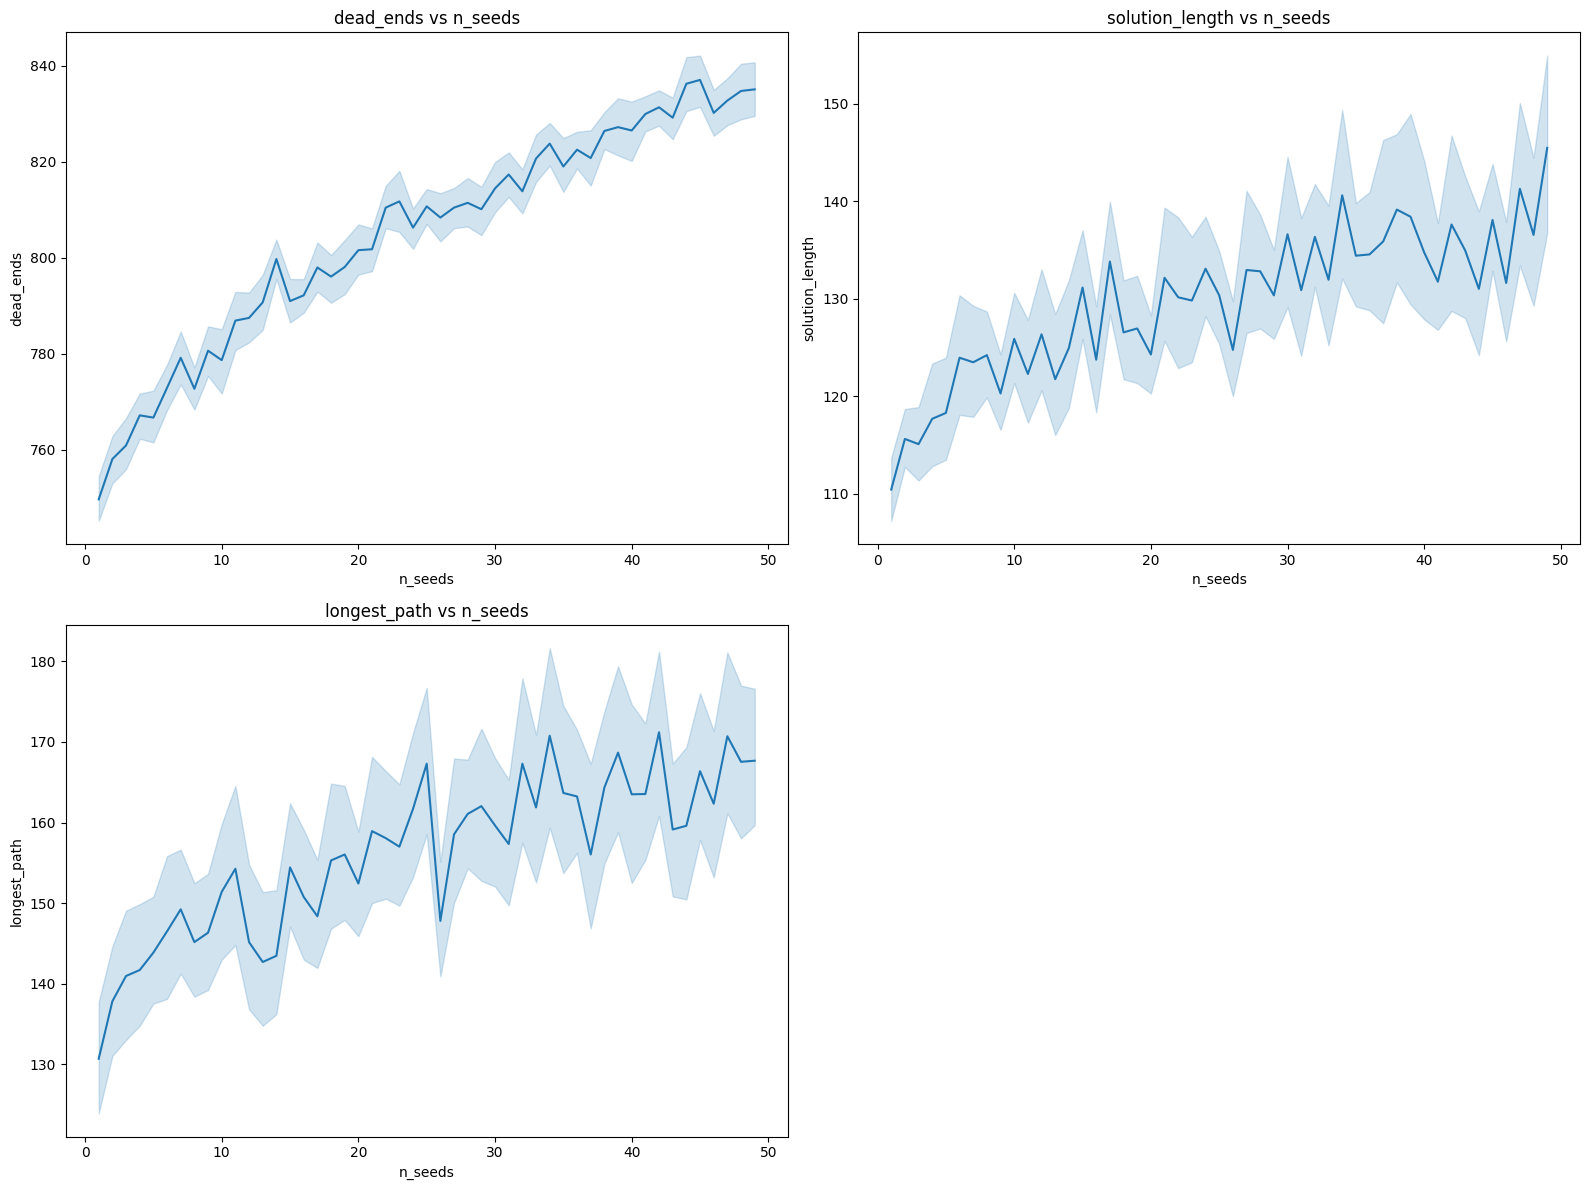

In [7]:
plt.figure(figsize=(16, 12))
for i, m in enumerate(metrics):
    plt.subplot(2, 2, i+1)
    sns.lineplot(data=df_seeds, x="n_seeds", y=m)
    plt.title(f"{m} vs n_seeds")

plt.tight_layout()
plt.show()

